# Phase 1 Database EDA

This notebook is a quick, repeatable audit of the database created after Phase 1 ingestion. It checks whether the three original data-stream families are present, whether the Twitter stream is complete enough for later analysis, and what early patterns should be understood before interpreting sentiment, topics, or statistical results.

**Scope guardrail:** the Twitter data is candidate-hashtag-centered and verified as `2020-10-15` through `2020-11-08`. It is not a complete Twitter firehose, public-opinion sample, January 6 dataset, or long-term protest dataset.

## How to use this notebook

Run this notebook after `verify/phase1/run_phase1.py` completes. The notebook reads the already-created Parquet and manifest files; it does not re-ingest raw CSV files.

The first half uses the full Phase 1 data for completeness checks. Text exploration uses a bounded sample by default because keyword and hashtag extraction over 1.7 million rows is slower and is meant here as an early warning system, not a final topic model.

In [1]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "output").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

TEXT_SAMPLE_SIZE = 100_000
RANDOM_STATE = 2020

print(f"Project root: {ROOT}")

Project root: d:\GW_UNIVERSITY\AIS\Social_Listener\Env\Social_Listener_V1\UOG_AIS_SOCIAL_LISTENER


## 1. Load Phase 1 artifacts

The manifest is the authoritative compact record of Phase 1 ingestion. The Parquet files are the analysis-ready database tables used by later phases.

In [2]:
def read_json(relative_path: str):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))


def read_parquet(relative_path: str) -> pd.DataFrame:
    path = ROOT / relative_path
    if not path.exists():
        raise FileNotFoundError(f"Missing required artifact: {path}")
    return pd.read_parquet(path)


manifest = read_json("output/results/phase1/ingestion_manifest.json")

trump = read_parquet("data/02_interim/twitter_donald_trump.parquet")
biden = read_parquet("data/02_interim/twitter_joe_biden.parquet")
events = read_parquet("data/02_interim/political_events.parquet")
returns = read_parquet("data/02_interim/electoral_returns.parquet")

twitter = pd.concat([trump, biden], ignore_index=True)
twitter["date"] = pd.to_datetime(twitter["date"], utc=True)
twitter["day"] = twitter["date"].dt.floor("D")

print(f"Twitter rows: {len(twitter):,}")
print(f"Events rows: {len(events):,}")
print(f"Electoral rows: {len(returns):,}")

Twitter rows: 1,747,542
Events rows: 4
Electoral rows: 51


## 2. Original PDF stream contract

The original project idea expects three data-stream families: social media, political events, and electoral benchmarks. This section verifies that each family exists and records whether it is complete enough for the original plan.

In [3]:
alignment = manifest.get("original_pdf_alignment", {}).get("streams", {})
alignment_rows = []
for stream_name, details in alignment.items():
    alignment_rows.append(
        {
            "stream": stream_name,
            "status": details.get("status"),
            "manifest_streams": ", ".join(details.get("manifest_streams", [])),
            "record_count": details.get("record_count"),
            "main_gaps": " | ".join(details.get("gaps", [])),
        }
    )

alignment_df = pd.DataFrame(alignment_rows)
alignment_df

,stream,status,manifest_streams,record_count,main_gaps
0,A_social_media,available_with_gaps,"twitter_donald_trump, twitter_joe_biden",1747542,Verified coverage is 2020-10-15 through 2020-1...
1,B_exogenous_events,available_with_gaps,political_events,4,Only four curated milestones are currently reg...
2,C_electoral_benchmarks,available_with_gaps,electoral_returns,51,Swing/safe classification currently uses the 2...


**Read this table conservatively.** `Available with gaps` means the stream exists in the codebase, but it does not yet satisfy every detail of the original PDF. For example, Stream A has the verified Kaggle window rather than the older planned window, Stream B currently has only four curated events, and Stream C lacks the original historical 2012/2016 swing-state classification and demographic controls.

## 3. Schema and record-count completeness

This is the first hard gate: if expected columns, row counts, date coverage, or core identifiers look wrong here, later sentiment and event interpretation should pause.

In [4]:
expected_twitter_columns = [
    "id",
    "date",
    "tweet",
    "user_id",
    "user_loc",
    "retweets",
    "replies",
    "candidate",
    "source_file",
]

schema_check = pd.DataFrame(
    {
        "expected_column": expected_twitter_columns,
        "present": [col in twitter.columns for col in expected_twitter_columns],
        "dtype": [str(twitter[col].dtype) if col in twitter.columns else None for col in expected_twitter_columns],
    }
)
schema_check

,expected_column,present,dtype
0,id,True,object
1,date,True,"datetime64[ms, UTC]"
2,tweet,True,object
3,user_id,True,object
4,user_loc,True,object
5,retweets,True,float64
6,replies,True,object
7,candidate,True,object
8,source_file,True,object


In [5]:
def summarize_stream(df: pd.DataFrame, label: str) -> dict:
    return {
        "stream": label,
        "records": len(df),
        "min_date": df["date"].min(),
        "max_date": df["date"].max(),
        "unique_days": df["day"].nunique(),
        "unique_users": df["user_id"].nunique(dropna=True),
        "missing_tweet": int(df["tweet"].isna().sum()),
        "missing_user_id": int(df["user_id"].isna().sum()),
        "missing_user_loc": int(df["user_loc"].isna().sum()),
        "missing_user_loc_pct": round(float(df["user_loc"].isna().mean() * 100), 2),
        "non_null_replies": int(df["replies"].notna().sum()),
    }


stream_summary = pd.DataFrame(
    [
        summarize_stream(trump.assign(day=trump["date"].dt.floor("D")), "donald_trump"),
        summarize_stream(biden.assign(day=biden["date"].dt.floor("D")), "joe_biden"),
        summarize_stream(twitter, "combined"),
    ]
)
stream_summary

,stream,records,min_date,max_date,unique_days,unique_users,missing_tweet,missing_user_id,missing_user_loc,missing_user_loc_pct,non_null_replies
0,donald_trump,970765,2020-10-15 00:00:01+00:00,2020-11-08 23:59:56+00:00,25,301350,0,0,0,0.0,0
1,joe_biden,776777,2020-10-15 00:00:01+00:00,2020-11-08 23:59:58+00:00,25,316051,0,0,0,0.0,0
2,combined,1747542,2020-10-15 00:00:01+00:00,2020-11-08 23:59:58+00:00,25,483175,0,0,0,0.0,0


In [6]:
expected_start = pd.Timestamp("2020-10-15", tz="UTC")
expected_end = pd.Timestamp("2020-11-08", tz="UTC")
expected_days = pd.date_range(expected_start, expected_end, freq="D")

coverage_rows = []
for candidate, group in twitter.groupby("candidate"):
    present_days = pd.DatetimeIndex(sorted(group["day"].dropna().unique()))
    missing_days = expected_days.difference(present_days)
    coverage_rows.append(
        {
            "candidate": candidate,
            "expected_days": len(expected_days),
            "present_days": len(present_days),
            "missing_days": ", ".join(day.strftime("%Y-%m-%d") for day in missing_days),
            "starts_on_expected_day": group["date"].min().date() == expected_start.date(),
            "ends_on_expected_day": group["date"].max().date() == expected_end.date(),
        }
    )

pd.DataFrame(coverage_rows)

,candidate,expected_days,present_days,missing_days,starts_on_expected_day,ends_on_expected_day
0,donald_trump,25,25,,True,True
1,joe_biden,25,25,,True,True


## 4. Period split before interpretation

Use this split throughout early analysis:

- `pre_election`: `2020-10-15` through `2020-11-02`
- `election_day`: `2020-11-03`
- `immediate_post`: `2020-11-04` through `2020-11-08`

The data can support before/during/immediate-after election analysis. It cannot support claims about longer post-election movements without adding data.

In [7]:
def assign_period(timestamp: pd.Timestamp) -> str:
    day = timestamp.date()
    if day <= pd.Timestamp("2020-11-02").date():
        return "pre_election"
    if day == pd.Timestamp("2020-11-03").date():
        return "election_day"
    return "immediate_post"


twitter["period"] = twitter["date"].map(assign_period)

period_counts = (
    twitter.pivot_table(index="period", columns="candidate", values="id", aggfunc="count", fill_value=0)
    .reindex(["pre_election", "election_day", "immediate_post"])
)
period_counts["combined"] = period_counts.sum(axis=1)
period_counts

candidate,donald_trump,joe_biden,combined
period,,,
pre_election,458110,311111,769221
election_day,67267,41495,108762
immediate_post,445388,424171,869559


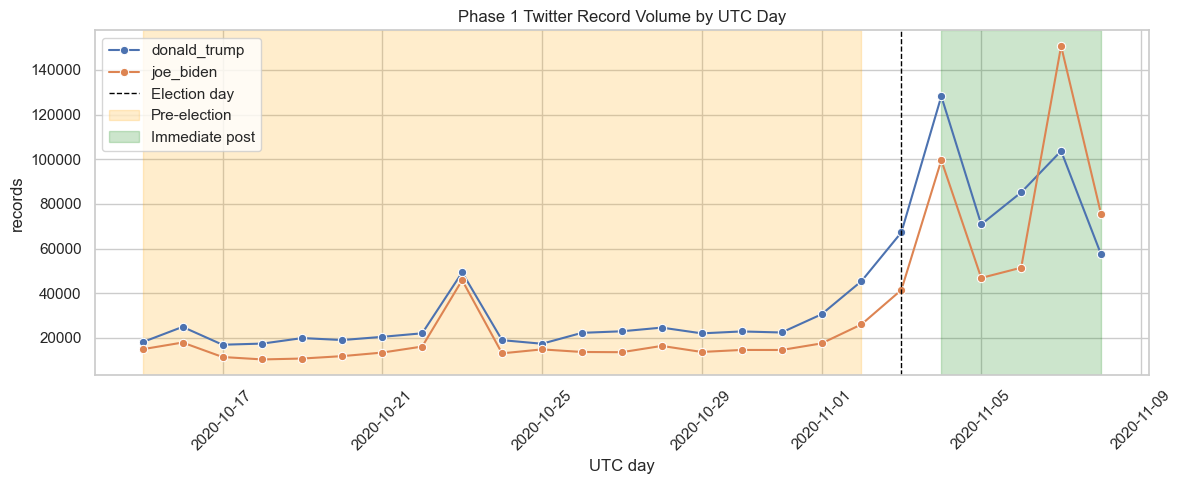

In [20]:
daily_counts = twitter.groupby(["day", "candidate"]).size().reset_index(name="records")

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_counts, x="day", y="records", hue="candidate", marker="o")

plt.axvline(
    pd.Timestamp("2020-11-03", tz="UTC"),
    color="black",
    linestyle="--",
    linewidth=1,
    label="Election day",
)

plt.axvspan(
    pd.Timestamp("2020-10-15", tz="UTC"),
    pd.Timestamp("2020-11-02", tz="UTC"),
    color="orange",
    alpha=0.2,
    label="Pre-election",
)

plt.axvspan(
    pd.Timestamp("2020-11-04", tz="UTC"),
    pd.Timestamp("2020-11-08", tz="UTC"),
    color="green",
    alpha=0.2,
    label="Immediate post",
)

plt.title("Phase 1 Twitter Record Volume by UTC Day")
plt.xlabel("UTC day")
plt.ylabel("records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

## 5. General findings to know before sentiment analysis

These descriptive checks are not final findings. They show dataset shape, imbalance, missingness, and concentration risks that can bias later sentiment or topic interpretation.

In [9]:
candidate_share = twitter["candidate"].value_counts().rename_axis("candidate").reset_index(name="records")
candidate_share["share_pct"] = (candidate_share["records"] / len(twitter) * 100).round(2)
candidate_share

,candidate,records,share_pct
0,donald_trump,970765,55.55
1,joe_biden,776777,44.45


In [10]:
missingness = (
    twitter[expected_twitter_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
)
missingness

,column,missing_pct
0,id,0.0
1,date,0.0
2,tweet,0.0
3,user_id,0.0
4,user_loc,0.0
5,retweets,0.0
6,replies,100.0
7,candidate,0.0
8,source_file,0.0


In [11]:
user_activity = twitter.groupby("user_id").size().rename("records").reset_index()
activity_summary = user_activity["records"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T
activity_summary["users"] = len(user_activity)
activity_summary["records_top_1pct_users"] = int(user_activity.nlargest(max(1, int(len(user_activity) * 0.01)), "records")["records"].sum())
activity_summary["top_1pct_record_share_pct"] = round(activity_summary["records_top_1pct_users"].iloc[0] / len(twitter) * 100, 2)
activity_summary

,count,mean,std,min,50%,75%,90%,95%,99%,max,users,records_top_1pct_users,top_1pct_record_share_pct
records,483175.0,3.616789,14.885863,1.0,1.0,2.0,6.0,11.0,41.0,2515.0,483175,479533,27.44


In [12]:
location_summary = (
    twitter.assign(has_user_loc=twitter["user_loc"].notna() & twitter["user_loc"].astype(str).str.strip().ne(""))
    .groupby(["candidate", "period"])["has_user_loc"]
    .agg(records="size", located_records="sum", location_coverage_pct=lambda s: round(float(s.mean() * 100), 2))
    .reset_index()
)
location_summary

,candidate,period,records,located_records,location_coverage_pct
0,donald_trump,election_day,67267,46397,68.97
1,donald_trump,immediate_post,445388,312335,70.13
2,donald_trump,pre_election,458110,316923,69.18
3,joe_biden,election_day,41495,29124,70.19
4,joe_biden,immediate_post,424171,304005,71.67
5,joe_biden,pre_election,311111,209776,67.43


**Interpretation guardrail:** missing `user_loc` is a spatial-analysis limitation, not an invalid tweet. Tweets without location can still support national temporal analysis, but they weaken state-level claims.

## 6. Event stream quick check

Stream B is present, but only four events are currently registered. Later event studies must decide whether this is sufficient or whether a fuller event timeline is needed.

In [13]:
events.sort_values("event_timestamp_utc")

,event_id,event_timestamp_utc,event_timezone,event_name,event_category,event_description,post_event_dummy,source_url
0,town_halls_2020_10_15,2020-10-16 00:00:00+00:00,America/New_York,Dueling presidential town halls,campaign_event,Joe Biden and Donald Trump participated in sep...,1,https://www.politifact.com/article/2020/oct/15...
1,presidential_debate_2020_10_22,2020-10-23 01:00:00+00:00,America/New_York,Final presidential debate,debate,Joe Biden and Donald Trump participated in the...,1,https://www.debates.org/debate-history/2020-de...
2,election_day_2020_11_03,2020-11-03 05:00:00+00:00,America/New_York,2020 presidential election day,election_day,The 2020 presidential general election was hel...,1,https://www.fec.gov/resources/cms-content/docu...
3,ap_projection_2020_11_07,2020-11-07 16:26:00+00:00,America/New_York,AP projects Joe Biden as president-elect,projection,The Associated Press declared Joe Biden the wi...,1,https://www.ap.org/the-definitive-source/behin...


In [14]:
event_windows = []
for _, event in events.sort_values("event_timestamp_utc").iterrows():
    center = pd.to_datetime(event["event_timestamp_utc"], utc=True)
    start = center - pd.Timedelta(days=1)
    end = center + pd.Timedelta(days=1)
    mask = twitter["date"].between(start, end, inclusive="both")
    event_windows.append(
        {
            "event_name": event["event_name"],
            "event_timestamp_utc": center,
            "records_plus_minus_1_day": int(mask.sum()),
            "trump_records": int((mask & twitter["candidate"].eq("donald_trump")).sum()),
            "biden_records": int((mask & twitter["candidate"].eq("joe_biden")).sum()),
        }
    )

pd.DataFrame(event_windows)

,event_name,event_timestamp_utc,records_plus_minus_1_day,trump_records,biden_records
0,Dueling presidential town halls,2020-10-16 00:00:00+00:00,75990,43092,32898
1,Final presidential debate,2020-10-23 01:00:00+00:00,133298,71312,61986
2,2020 presidential election day,2020-11-03 05:00:00+00:00,215233,132112,83121
3,AP projects Joe Biden as president-elect,2020-11-07 16:26:00+00:00,394787,168311,226476


If an event falls outside the verified Twitter window, its event-window count should be zero or partial. That is a coverage issue, not preprocessing exclusion.

## 7. Electoral benchmark quick check

Stream C is present as state-level electoral returns. The current `state_classification` is useful for exploratory grouping, but the Phase 1 alignment audit notes that it is not yet the original PDF's requested historical 2012/2016 classification.

In [15]:
returns_summary = pd.DataFrame(
    [
        {
            "states_or_dc_rows": len(returns),
            "unique_state_codes": returns["state_code"].nunique(),
            "biden_won_rows": int((returns["winner"] == "biden").sum()),
            "trump_won_rows": int((returns["winner"] == "trump").sum()),
            "min_abs_margin_pct": returns["absolute_margin_pct"].min(),
            "median_abs_margin_pct": returns["absolute_margin_pct"].median(),
            "max_abs_margin_pct": returns["absolute_margin_pct"].max(),
        }
    ]
)
returns_summary

,states_or_dc_rows,unique_state_codes,biden_won_rows,trump_won_rows,min_abs_margin_pct,median_abs_margin_pct,max_abs_margin_pct
0,51,51,0,0,0.235582,16.545348,86.752373


In [16]:
returns.groupby(["winner", "state_classification"]).size().rename("states_or_dc_rows").reset_index()

,winner,state_classification,states_or_dc_rows
0,Biden,safe,20
1,Biden,swing,6
2,Trump,safe,23
3,Trump,swing,2


## 8. Fast keyword and hashtag reconnaissance

This section helps decide what topics deserve a formal Phase 3/4 topic audit. It is not a final topic model and should not be cited as proof of topic dominance.

In [17]:
text_sample = twitter.sample(n=min(TEXT_SAMPLE_SIZE, len(twitter)), random_state=RANDOM_STATE).copy()
text_sample["tweet_text"] = text_sample["tweet"].fillna("").astype(str)

hashtag_pattern = re.compile(r"(?<!\w)#([A-Za-z0-9_]+)")

hashtags = []
for row in text_sample[["candidate", "period", "tweet_text"]].itertuples(index=False):
    for tag in hashtag_pattern.findall(row.tweet_text):
        hashtags.append({"candidate": row.candidate, "period": row.period, "hashtag": tag.lower()})

hashtags_df = pd.DataFrame(hashtags)
top_hashtags = (
    hashtags_df.groupby(["period", "candidate", "hashtag"]).size().rename("sample_count").reset_index()
    if not hashtags_df.empty
    else pd.DataFrame(columns=["period", "candidate", "hashtag", "sample_count"])
)

top_hashtags.sort_values(["period", "candidate", "sample_count"], ascending=[True, True, False]).groupby(["period", "candidate"]).head(10)

,period,candidate,hashtag,sample_count
2951,election_day,donald_trump,trump,3514
341,election_day,donald_trump,biden,797
964,election_day,donald_trump,electionday,588
882,election_day,donald_trump,donaldtrump,561
961,election_day,donald_trump,election2020,446
2952,election_day,donald_trump,trump2020,422
976,election_day,donald_trump,elections2020,345
3305,election_day,donald_trump,vote,340
1806,election_day,donald_trump,maga,239
1575,election_day,donald_trump,joebiden,218


In [18]:
STOPWORDS = {
    "the", "and", "for", "you", "that", "this", "with", "are", "was", "from", "have", "not", "but", "all", "can", "our",
    "has", "his", "her", "she", "him", "they", "them", "your", "will", "just", "about", "what", "when", "who", "why", "how",
    "https", "http", "amp", "rt", "co", "www", "com", "donaldtrump", "joebiden", "trump", "biden", "election2020",
}
word_pattern = re.compile(r"[A-Za-z][A-Za-z']+")


def extract_terms(text: str) -> list[str]:
    return [w.lower() for w in word_pattern.findall(text) if len(w) >= 3 and w.lower() not in STOPWORDS]


terms = []
for row in text_sample[["candidate", "period", "tweet_text"]].itertuples(index=False):
    for term in extract_terms(row.tweet_text):
        terms.append({"candidate": row.candidate, "period": row.period, "term": term})

terms_df = pd.DataFrame(terms)
top_terms = (
    terms_df.groupby(["period", "candidate", "term"]).size().rename("sample_count").reset_index()
    if not terms_df.empty
    else pd.DataFrame(columns=["period", "candidate", "term", "sample_count"])
)

top_terms.sort_values(["period", "candidate", "sample_count"], ascending=[True, True, False]).groupby(["period", "candidate"]).head(15)

,period,candidate,term,sample_count
18150,election_day,donald_trump,vote,830
5015,election_day,donald_trump,election,754
5018,election_day,donald_trump,electionday,620
5028,election_day,donald_trump,elections,458
13903,election_day,donald_trump,realdonaldtrump,367
...,...,...,...,...
286979,pre_election,joe_biden,people,886
264212,pre_election,joe_biden,debate,854
279643,pre_election,joe_biden,like,782
277530,pre_election,joe_biden,kamalaharris,777


## 9. Early interpretation checklist

Before using this dataset for findings, answer these checks from the tables above:

- Are all three original stream families present? If yes, which gaps remain?
- Does Twitter coverage match the verified `2020-10-15` to `2020-11-08` window?
- Are candidate streams imbalanced enough to affect aggregate summaries?
- Is location coverage strong enough for the state-level question you want to ask?
- Are a small number of high-volume users likely to affect totals?
- Are the event windows inside the verified Twitter coverage?
- Do top terms and hashtags suggest topics worth testing formally, rather than assuming topics from outside datasets?

Use this notebook to decide what needs deeper analysis. Do not treat these quick diagnostics as final sentiment, topic, or causal findings.